# Heart Failure Mortality Risk Analytics

## 1. Imports
Import all necessary libraries for data manipulation, visualization, SQL interaction, and machine learning.

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


## 2. Load and Explore Data
Load the `heart_failure_clinical_records_dataset.csv` file into a pandas DataFrame and perform initial data exploration.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Path to dataset files: /kaggle/input/heart-failure-clinical-data


In [ ]:
import kagglehub
import os # Import the os module

# Download latest version
path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
csv_file_name = 'heart_failure_clinical_records_dataset.csv'
full_csv_path = os.path.join(path, csv_file_name)

try:
    # Read the CSV file using the full path
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded '{full_csv_path}'")
except FileNotFoundError:
    print(f"Error: '{full_csv_path}' not found. Please ensure the file exists within the downloaded directory.")
    df = None # Set df to None to avoid errors in subsequent steps if file is not found

if df is not None:
    print("\n--- Dataset Shape ---")
    print(df.shape)

    print("\n--- First 5 Rows ---")
    display(df.head())

    print("\n--- Dataset Info ---")
    df.info()

    print("\n--- Descriptive Statistics ---")
    display(df.describe())

    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    print("\n--- Duplicate Rows ---")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")

    print("\n--- Target Class Balance (DEATH_EVENT) ---")
    print(df['DEATH_EVENT'].value_counts())
    print(f"Survival Rate: {(df['DEATH_EVENT'].value_counts()[0] / len(df) * 100):.2f}% (0 = survived)")
    print(f"Mortality Rate: {(df['DEATH_EVENT'].value_counts()[1] / len(df) * 100):.2f}% (1 = patient died)")


Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Path to dataset files: /kaggle/input/heart-failure-clinical-data
Successfully loaded '/kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv'

--- Dataset Shape ---
(299, 13)

--- First 5 Rows ---


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000



--- Missing Values ---
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 0

--- Target Class Balance (DEATH_EVENT) ---
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
Survival Rate: 67.89% (0 = survived)
Mortality Rate: 32.11% (1 = patient died)


## 3. Data Cleaning and Data Quality Report
Clean the dataset by removing duplicates, handling missing values, detecting and capping outliers, and creating new descriptive features. Generate a data quality report summarizing these changes.

In [ ]:
if df is None:
    print("Cannot perform data cleaning: DataFrame is not loaded. Please upload the file and run previous cells.")
else:
    # Initialize data quality report
    data_quality_report = {
        'rows_before_cleaning': len(df),
        'duplicates_removed': 0,
        'missing_values_found': {},
        'outliers_capped_per_column': {}
    }

    # --- 3.1 Check and remove duplicates ---
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    duplicates_removed_count = initial_rows - df.shape[0]
    data_quality_report['duplicates_removed'] = duplicates_removed_count
    print(f"Removed {duplicates_removed_count} duplicate rows.")

    # --- 3.2 Check missing values ---
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    if not missing_values.empty:
        data_quality_report['missing_values_found'] = missing_values.to_dict()
        print("\nMissing values found:")
        print(missing_values)
        # For this dataset, no missing values are expected, so we'll just report them if found.
        # If any were found, a strategy like imputation would be applied here.
    else:
        print("\nNo missing values found.")

    # Create a copy for capping outliers to preserve raw values
    df_cleaned = df.copy()

    # --- 3.3 Detect outliers with the IQR rule and cap them ---
    outlier_cols = ['creatinine_phosphokinase', 'serum_creatinine', 'platelets', 'serum_sodium', 'ejection_fraction']
    print("\n--- Outlier Detection and Capping ---")

    for col in outlier_cols:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers_count = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]
        data_quality_report['outliers_capped_per_column'][col] = outliers_count
        print(f"Column '{col}': {outliers_count} outliers detected (min: {lower_bound:.2f}, max: {upper_bound:.2f}).")

        # Cap outliers in new columns (or overwrite if that's the approach chosen)
        # For this project, we will cap them directly in the df_cleaned to simplify for modeling.
        # Note: Extreme values in medical data can be clinically real, not just errors.
        # Capping is a modeling choice to reduce the impact of extreme values on certain algorithms.
        # For clinical interpretation, raw values are often preferred.
        df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])
        df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])

    # --- 3.4 Create readable labels ---
    df_cleaned['sex_label'] = df_cleaned['sex'].map({1: 'Male', 0: 'Female'})
    df_cleaned['anaemia_label'] = df_cleaned['anaemia'].map({1: 'Yes', 0: 'No'})
    df_cleaned['diabetes_label'] = df_cleaned['diabetes'].map({1: 'Yes', 0: 'No'})
    df_cleaned['high_blood_pressure_label'] = df_cleaned['high_blood_pressure'].map({1: 'Yes', 0: 'No'})
    df_cleaned['smoking_label'] = df_cleaned['smoking'].map({1: 'Yes', 0: 'No'})

    # --- 3.5 Create age_group ---
    bins = [0, 50, 60, 70, np.inf]
    labels = ['<50', '50-59', '60-69', '70+']
    df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=bins, labels=labels, right=False)

    # --- 3.6 Create ef_category from ejection_fraction ---
    def get_ef_category(ef):
        if ef <= 30: return 'Severe'
        elif 31 <= ef <= 40: return 'Reduced'
        elif 41 <= ef <= 49: return 'Borderline'
        else: return 'Normal'
    df_cleaned['ef_category'] = df_cleaned['ejection_fraction'].apply(get_ef_category)

    # --- 3.7 Create creatinine_level ---
    df_cleaned['creatinine_level'] = df_cleaned['serum_creatinine'].apply(lambda x: 'High' if x > 1.2 else 'Normal')

    # --- 3.8 Create outcome_label ---
    df_cleaned['outcome_label'] = df_cleaned['DEATH_EVENT'].map({1: 'Died', 0: 'Survived'})

    # Final update to data quality report
    data_quality_report['rows_after_cleaning'] = len(df_cleaned)
    print("\n--- Data Quality Report ---")
    print(data_quality_report)

    print("\n--- Cleaned DataFrame Head (with new features) ---")
    display(df_cleaned.head())


Removed 0 duplicate rows.

No missing values found.

--- Outlier Detection and Capping ---
Column 'creatinine_phosphokinase': 29 outliers detected (min: -581.75, max: 1280.25).
Column 'serum_creatinine': 29 outliers detected (min: 0.15, max: 2.15).
Column 'platelets': 21 outliers detected (min: 76000.00, max: 440000.00).
Column 'serum_sodium': 4 outliers detected (min: 125.00, max: 149.00).
Column 'ejection_fraction': 2 outliers detected (min: 7.50, max: 67.50).

--- Data Quality Report ---
{'rows_before_cleaning': 299, 'duplicates_removed': 0, 'missing_values_found': {}, 'outliers_capped_per_column': {'creatinine_phosphokinase': 29, 'serum_creatinine': 29, 'platelets': 21, 'serum_sodium': 4, 'ejection_fraction': 2}, 'rows_after_cleaning': 299}

--- Cleaned DataFrame Head (with new features) ---


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,...,DEATH_EVENT,sex_label,anaemia_label,diabetes_label,high_blood_pressure_label,smoking_label,age_group,ef_category,creatinine_level,outcome_label
0,75.0,0,582.00,0,20.0,1,265000.00,1.90,130.0,1,...,1,Male,No,No,Yes,No,70+,Severe,High,Died
1,55.0,0,1280.25,0,38.0,0,263358.03,1.10,136.0,1,...,1,Male,No,No,No,No,50-59,Reduced,Normal,Died
2,65.0,0,146.00,0,20.0,0,162000.00,1.30,129.0,1,...,1,Male,No,No,No,Yes,60-69,Severe,High,Died
3,50.0,1,111.00,0,20.0,0,210000.00,1.90,137.0,1,...,1,Male,Yes,No,No,No,50-59,Severe,High,Died
4,65.0,1,160.00,1,20.0,0,327000.00,2.15,125.0,0,...,1,Female,Yes,Yes,No,No,60-69,Severe,High,Died


## 4. Exploratory Visualizations
Visualize data distributions, correlations, and key relationships to understand patterns and anomalies.

/tmp/ipykernel_664/705509573.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_by_age = df_cleaned.groupby('age_group')['DEATH_EVENT'].value_counts(normalize=True).unstack().fillna(0)
/tmp/ipykernel_664/705509573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mortality_by_age.index, y='Mortality_Rate', data=mortality_by_age, palette='viridis')


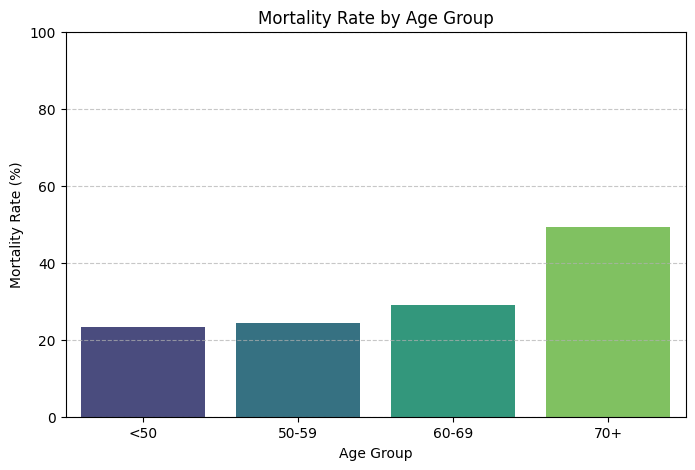

In [ ]:
# --- Mortality Rate by Age Group ---
mortality_by_age = df_cleaned.groupby('age_group')['DEATH_EVENT'].value_counts(normalize=True).unstack().fillna(0)
mortality_by_age['Mortality_Rate'] = mortality_by_age[1] * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=mortality_by_age.index, y='Mortality_Rate', data=mortality_by_age, palette='viridis')
plt.title('Mortality Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipykernel_664/1943684059.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mortality_by_ef.index, y='Mortality_Rate', data=mortality_by_ef, palette='magma')


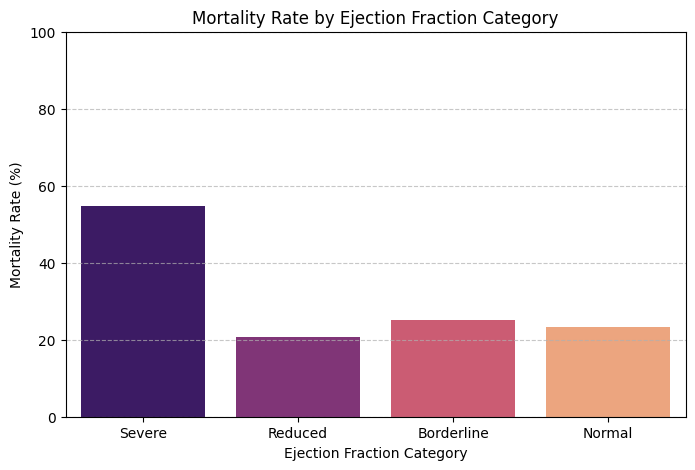

In [ ]:
# --- Mortality Rate by Ejection Fraction Category ---
mortality_by_ef = df_cleaned.groupby('ef_category')['DEATH_EVENT'].value_counts(normalize=True).unstack().fillna(0)
mortality_by_ef['Mortality_Rate'] = mortality_by_ef[1] * 100

# Order categories for better visualization
ef_order = ['Severe', 'Reduced', 'Borderline', 'Normal']
mortality_by_ef = mortality_by_ef.reindex(ef_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=mortality_by_ef.index, y='Mortality_Rate', data=mortality_by_ef, palette='magma')
plt.title('Mortality Rate by Ejection Fraction Category')
plt.xlabel('Ejection Fraction Category')
plt.ylabel('Mortality Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipykernel_664/1541467447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome_label', y='serum_creatinine', data=df_cleaned, palette='coolwarm', ax=axes[0])
/tmp/ipykernel_664/1541467447.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome_label', y='ejection_fraction', data=df_cleaned, palette='coolwarm', ax=axes[1])


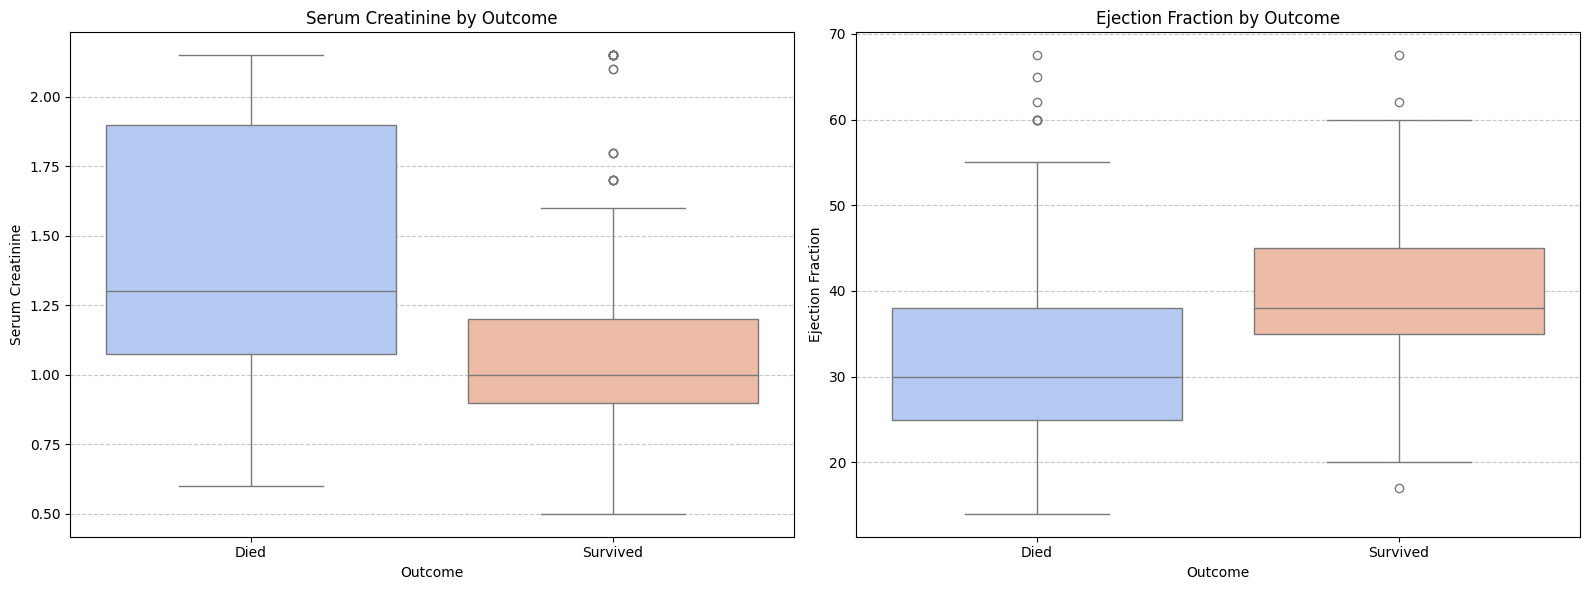

In [ ]:
# --- Boxplots of key features by Outcome ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for serum_creatinine by outcome
sns.boxplot(x='outcome_label', y='serum_creatinine', data=df_cleaned, palette='coolwarm', ax=axes[0])
axes[0].set_title('Serum Creatinine by Outcome')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Serum Creatinine')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot for ejection_fraction by outcome
sns.boxplot(x='outcome_label', y='ejection_fraction', data=df_cleaned, palette='coolwarm', ax=axes[1])
axes[1].set_title('Ejection Fraction by Outcome')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Ejection Fraction')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


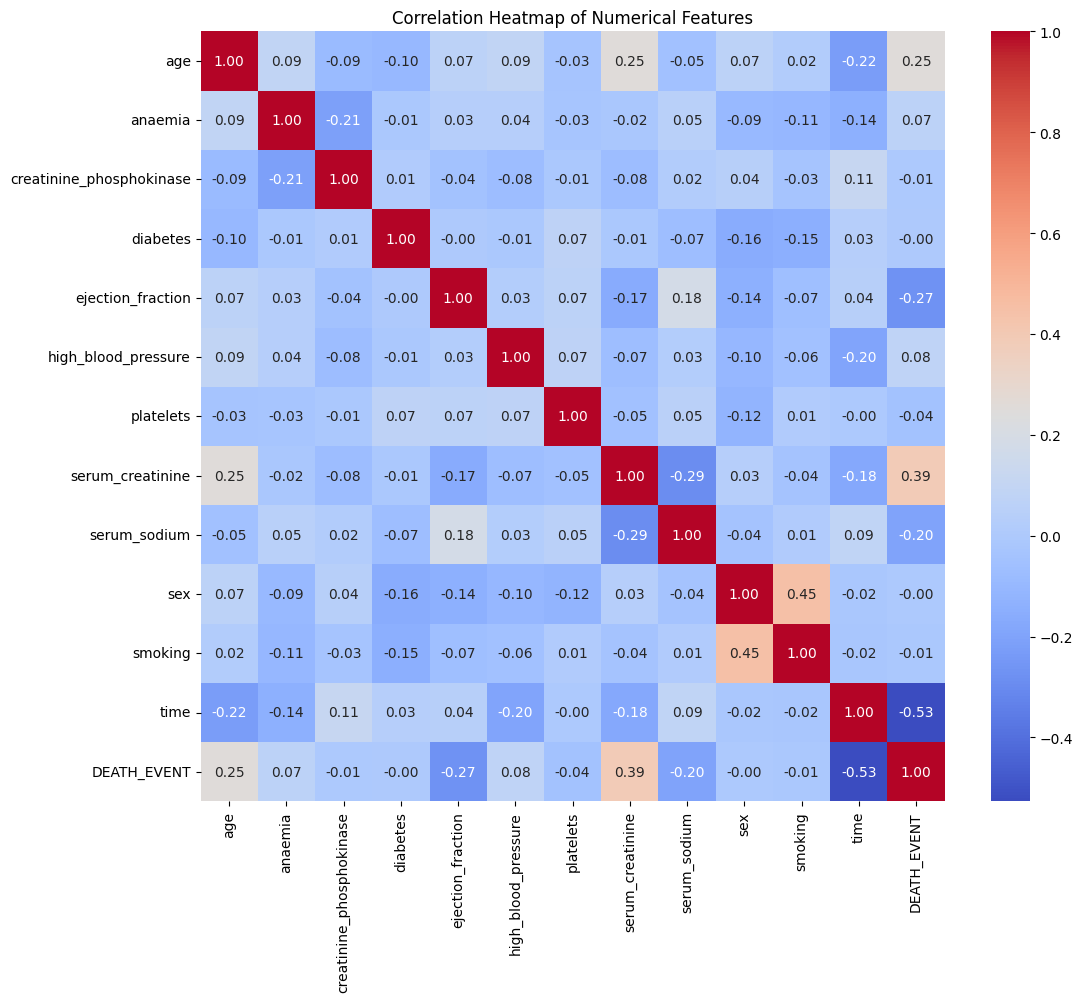

In [ ]:
# --- Correlation Heatmap ---
# Select only numerical columns for correlation calculation
numerical_df = df_cleaned.select_dtypes(include=np.number)
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


/tmp/ipykernel_664/2684995568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='outcome_label', data=df_cleaned, palette='pastel')


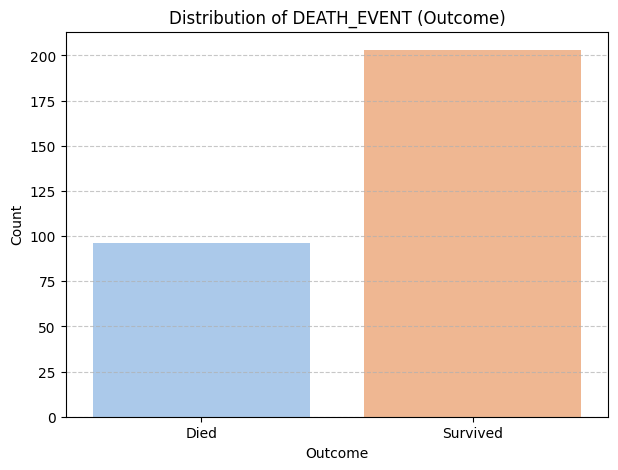

In [ ]:
# --- Target Class Balance Count ---
plt.figure(figsize=(7, 5))
sns.countplot(x='outcome_label', data=df_cleaned, palette='pastel')
plt.title('Distribution of DEATH_EVENT (Outcome)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 5. SQL Analysis
Save the cleaned DataFrame to a SQLite database and query it to extract specific insights.

In [ ]:
# Create a SQLite database in memory or a file
conn = sqlite3.connect('heart_failure.db')

# Save the cleaned DataFrame to a SQL table named 'heart'
df_cleaned.to_sql('heart', conn, if_exists='replace', index=False)
print("DataFrame 'df_cleaned' saved to SQLite database 'heart_failure.db' as table 'heart'.")

# Helper function to run SQL queries and return a DataFrame
def run_query(query):
    return pd.read_sql_query(query, conn)

print("Helper function 'run_query' created.")


DataFrame 'df_cleaned' saved to SQLite database 'heart_failure.db' as table 'heart'.
Helper function 'run_query' created.


### 5.1 Overall mortality rate

In [ ]:
query = """
SELECT
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart;
"""
overall_mortality = run_query(query)
print("Overall Mortality Rate:")
display(overall_mortality)


Overall Mortality Rate:


,TotalPatients,Deaths,MortalityRatePercentage
0,299,96,32.107023


### 5.2 Mortality rate by age_group

In [ ]:
query = """
SELECT
    age_group,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    age_group
ORDER BY
    age_group;
"""
mortality_by_age_group = run_query(query)
print("Mortality Rate by Age Group:")
display(mortality_by_age_group)


Mortality Rate by Age Group:


,age_group,TotalPatients,Deaths,MortalityRatePercentage
0,50-59,82,20,24.390244
1,60-69,93,27,29.032258
2,70+,77,38,49.350649
3,<50,47,11,23.404255


### 5.3 Mortality rate by sex_label

In [ ]:
query = """
SELECT
    sex_label,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    sex_label;
"""
mortality_by_sex = run_query(query)
print("Mortality Rate by Sex Label:")
display(mortality_by_sex)


Mortality Rate by Sex Label:


,sex_label,TotalPatients,Deaths,MortalityRatePercentage
0,Female,105,34,32.380952
1,Male,194,62,31.958763


### 5.4 Average serum_creatinine, ejection_fraction and serum_sodium by outcome

In [ ]:
query = """
SELECT
    outcome_label,
    AVG(serum_creatinine) AS AvgSerumCreatinine,
    AVG(ejection_fraction) AS AvgEjectionFraction,
    AVG(serum_sodium) AS AvgSerumSodium
FROM
    heart
GROUP BY
    outcome_label;
"""
avg_metrics_by_outcome = run_query(query)
print("Average Serum Creatinine, Ejection Fraction, and Serum Sodium by Outcome:")
display(avg_metrics_by_outcome)


Average Serum Creatinine, Ejection Fraction, and Serum Sodium by Outcome:


,outcome_label,AvgSerumCreatinine,AvgEjectionFraction,AvgSerumSodium
0,Died,1.482708,33.442708,135.520833
1,Survived,1.117143,40.204433,137.275862


### 5.5 Mortality rate by ef_category

In [ ]:
query = """
SELECT
    ef_category,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    ef_category
ORDER BY
    CASE ef_category
        WHEN 'Severe' THEN 1
        WHEN 'Reduced' THEN 2
        WHEN 'Borderline' THEN 3
        WHEN 'Normal' THEN 4
    END;
"""
mortality_by_ef_category = run_query(query)
print("Mortality Rate by Ejection Fraction Category:")
display(mortality_by_ef_category)


Mortality Rate by Ejection Fraction Category:


,ef_category,TotalPatients,Deaths,MortalityRatePercentage
0,Severe,93,51,54.838710
1,Reduced,126,26,20.634921
2,Borderline,20,5,25.000000
3,Normal,60,14,23.333333


### 5.6 Mortality rate by high_blood_pressure, diabetes, anaemia and smoking (combined query)

In [ ]:
query = """
SELECT
    'High Blood Pressure' AS Factor,
    high_blood_pressure_label AS Status,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    Status

UNION ALL

SELECT
    'Diabetes' AS Factor,
    diabetes_label AS Status,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    Status

UNION ALL

SELECT
    'Anaemia' AS Factor,
    anaemia_label AS Status,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    Status

UNION ALL

SELECT
    'Smoking' AS Factor,
    smoking_label AS Status,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    Status;
"""
mortality_by_factors = run_query(query)
print("Mortality Rate by High Blood Pressure, Diabetes, Anaemia, and Smoking:")
display(mortality_by_factors)


Mortality Rate by High Blood Pressure, Diabetes, Anaemia, and Smoking:


,Factor,Status,TotalPatients,Deaths,MortalityRatePercentage
0,High Blood Pressure,No,194,57,29.381443
1,High Blood Pressure,Yes,105,39,37.142857
2,Diabetes,No,174,56,32.183908
3,Diabetes,Yes,125,40,32.000000
4,Anaemia,No,170,50,29.411765
5,Anaemia,Yes,129,46,35.658915
6,Smoking,No,203,66,32.512315
7,Smoking,Yes,96,30,31.250000


### 5.7 Window function: RANK() of age groups by mortality rate

In [ ]:
query = """
WITH AgeGroupMortality AS (
    SELECT
        age_group,
        CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
    FROM
        heart
    GROUP BY
        age_group
)
SELECT
    age_group,
    MortalityRatePercentage,
    RANK() OVER (ORDER BY MortalityRatePercentage DESC) AS RankMortality
FROM
    AgeGroupMortality
ORDER BY
    RankMortality;
"""
rank_age_group_mortality = run_query(query)
print("Rank of Age Groups by Mortality Rate:")
display(rank_age_group_mortality)


Rank of Age Groups by Mortality Rate:


,age_group,MortalityRatePercentage,RankMortality
0,70+,49.350649,1
1,60-69,29.032258,2
2,50-59,24.390244,3
3,<50,23.404255,4


### 5.8 Top 5 highest-risk segments combining age_group and ef_category (with at least 10 patients each)

In [ ]:
query = """
SELECT
    age_group,
    ef_category,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage
FROM
    heart
GROUP BY
    age_group, ef_category
HAVING
    COUNT(*) >= 10
ORDER BY
    MortalityRatePercentage DESC
LIMIT 5;
"""
highest_risk_segments = run_query(query)
print("Top 5 Highest-Risk Segments (Age Group & EF Category, >= 10 Patients):")
display(highest_risk_segments)


Top 5 Highest-Risk Segments (Age Group & EF Category, >= 10 Patients):


,age_group,ef_category,TotalPatients,Deaths,MortalityRatePercentage
0,70+,Severe,20,15,75.000000
1,<50,Severe,16,9,56.250000
2,60-69,Severe,31,16,51.612903
3,50-59,Severe,26,11,42.307692
4,70+,Reduced,31,12,38.709677


### 5.9 Mortality rate by creatinine_level, with average ejection_fraction

In [ ]:
query = """
SELECT
    creatinine_level,
    COUNT(*) AS TotalPatients,
    SUM(DEATH_EVENT) AS Deaths,
    CAST(SUM(DEATH_EVENT) AS REAL) * 100 / COUNT(*) AS MortalityRatePercentage,
    AVG(ejection_fraction) AS AvgEjectionFraction
FROM
    heart
GROUP BY
    creatinine_level;
"""
mortality_by_creatinine_level = run_query(query)
print("Mortality Rate by Creatinine Level with Average Ejection Fraction:")
display(mortality_by_creatinine_level)


Mortality Rate by Creatinine Level with Average Ejection Fraction:


,creatinine_level,TotalPatients,Deaths,MortalityRatePercentage,AvgEjectionFraction
0,High,101,54,53.465347,35.668317
1,Normal,198,42,21.212121,39.239899


### 5.10 Window function: for each patient, show serum_creatinine vs the average of their age_group, and list the top 10 differences.

In [ ]:
query = """
WITH PatientCreatinine AS (
    SELECT
        age_group,
        serum_creatinine,
        AVG(serum_creatinine) OVER (PARTITION BY age_group) AS AvgCreatinineAgeGroup,
        ABS(serum_creatinine - AVG(serum_creatinine) OVER (PARTITION BY age_group)) AS CreatinineDifference
    FROM
        heart
)
SELECT
    age_group,
    serum_creatinine,
    AvgCreatinineAgeGroup,
    CreatinineDifference
FROM
    PatientCreatinine
ORDER BY
    CreatinineDifference DESC
LIMIT 10;
"""
creatinine_diff_top10 = run_query(query)
print("Top 10 Patients with Largest Serum Creatinine Difference from Age Group Average:")
display(creatinine_diff_top10)

# Close the connection when done
conn.close()
print("\nSQLite database connection closed.")


Top 10 Patients with Largest Serum Creatinine Difference from Age Group Average:


,age_group,serum_creatinine,AvgCreatinineAgeGroup,CreatinineDifference
0,<50,2.15,1.095106,1.054894
1,50-59,2.15,1.118780,1.031220
2,50-59,2.15,1.118780,1.031220
3,50-59,2.15,1.118780,1.031220
4,50-59,2.15,1.118780,1.031220
5,50-59,2.15,1.118780,1.031220
6,<50,2.10,1.095106,1.004894
7,60-69,2.15,1.294194,0.855806
8,60-69,2.15,1.294194,0.855806
9,60-69,2.15,1.294194,0.855806



SQLite database connection closed.


### SQL Analysis Summary and Insights
Based on the SQL queries, here's a summary of key numbers and placeholders for insights:

**Key Numbers for Insights:**


In [ ]:
print("Overall Mortality Rate (%):")
display(overall_mortality)

print("\nMortality Rate by Age Group (%):")
display(mortality_by_age_group)

print("\nMortality Rate by Ejection Fraction Category (%):")
display(mortality_by_ef_category)

print("\nAverage Serum Creatinine by Outcome:")
display(avg_metrics_by_outcome)

print("\nTop 5 Highest-Risk Segments:")
display(highest_risk_segments)

print("\nMortality Rate by Creatinine Level:")
display(mortality_by_creatinine_level)


Overall Mortality Rate (%):


,TotalPatients,Deaths,MortalityRatePercentage
0,299,96,32.107023



Mortality Rate by Age Group (%):


,age_group,TotalPatients,Deaths,MortalityRatePercentage
0,50-59,82,20,24.390244
1,60-69,93,27,29.032258
2,70+,77,38,49.350649
3,<50,47,11,23.404255



Mortality Rate by Ejection Fraction Category (%):


...

,outcome_label,AvgSerumCreatinine,AvgEjectionFraction,AvgSerumSodium
0,Died,1.482708,33.442708,135.520833
1,Survived,1.117143,40.204433,137.275862



Top 5 Highest-Risk Segments:


,age_group,ef_category,TotalPatients,Deaths,MortalityRatePercentage
0,70+,Severe,20,15,75.000000
1,<50,Severe,16,9,56.250000
2,60-69,Severe,31,16,51.612903
3,50-59,Severe,26,11,42.307692
4,70+,Reduced,31,12,38.709677



Mortality Rate by Creatinine Level:


,creatinine_level,TotalPatients,Deaths,MortalityRatePercentage,AvgEjectionFraction
0,High,101,54,53.465347,35.668317
1,Normal,198,42,21.212121,39.239899


## 6. Machine Learning
Train and evaluate machine learning models (Logistic Regression and Random Forest) to predict `DEATH_EVENT`.

In [ ]:
# Define features (X) and target (y)
# IMPORTANT: EXCLUDE the 'time' column from the features because it is follow-up duration and leaks the outcome.
features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction',
            'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

X = df_cleaned[features]
y = df_cleaned['DEATH_EVENT']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Features (X) shape: (299, 11)
Target (y) shape: (299,)
X_train shape: (239, 11), y_train shape: (239,)
X_test shape: (60, 11), y_test shape: (60,)


### 6.1 Model Training and Evaluation
Train Logistic Regression and Random Forest models, and compare their performance using various metrics.

In [ ]:
# --- Logistic Regression Model ---
# Use a pipeline for scaling and logistic regression
log_reg_pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear'))
log_reg_pipeline.fit(X_train, y_train)

y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

# --- Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# --- Evaluation Metrics Function ---
def evaluate_model(y_true, y_pred, y_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    return {'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'ROC-AUC': roc_auc}

# Get metrics for both models
log_reg_metrics = evaluate_model(y_test, y_pred_log_reg, y_proba_log_reg, 'Logistic Regression')
rf_metrics = evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest')

metrics_df = pd.DataFrame([log_reg_metrics, rf_metrics]).set_index('Model')

print("\n--- Model Comparison ---")
display(metrics_df)

# --- Cross-validated ROC-AUC for Random Forest ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc_auc_rf = cross_val_predict(rf_model, X, y, cv=skf, method='predict_proba')[:, 1]
cv_roc_auc_score_rf = roc_auc_score(y, cv_roc_auc_rf)
print(f"\nRandom Forest 5-fold Cross-Validated ROC-AUC: {cv_roc_auc_score_rf:.4f}")



--- Model Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.65,0.454545,0.526316,0.487805,0.709884
Random Forest,0.75,0.625000,0.526316,0.571429,0.793325



Random Forest 5-fold Cross-Validated ROC-AUC: 0.7622


### 6.2 Random Forest Detailed Analysis
Classification report, confusion matrix, and feature importance for the Random Forest model.


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        41
           1       0.62      0.53      0.57        19

    accuracy                           0.75        60
   macro avg       0.71      0.69      0.70        60
weighted avg       0.74      0.75      0.74        60



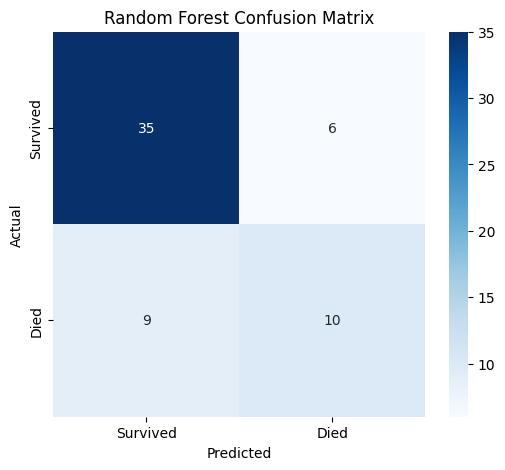

/tmp/ipykernel_664/1296442703.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


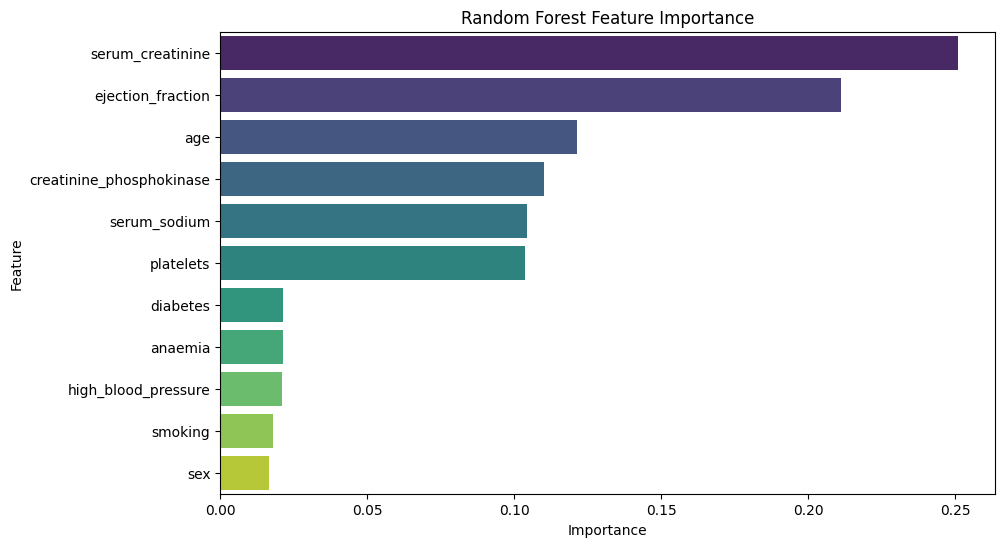

In [ ]:
# --- Classification Report (Random Forest) ---
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# --- Confusion Matrix (Random Forest) ---
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Feature Importance (Random Forest) ---
feature_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


### Note on Recall
In healthcare, especially when predicting mortality, **recall** is often considered the most critical metric. A high recall means that the model is good at identifying most of the patients who *will* die (minimizing false negatives). Missing a high-risk patient (a false negative) can have severe consequences, whereas incorrectly identifying a healthy patient as high-risk (a false positive) is generally less detrimental, though still undesirable.

## 6.3 Threshold Tuning for Improved Recall

Optimizing the classification threshold to achieve better recall, which is crucial in healthcare contexts to minimize false negatives (missed high-risk patients).

In [ ]:
# A.1: Test thresholds and show results table

# Assuming y_proba_rf from the test set is available, or regenerate predictions for the whole dataset
# For threshold tuning, it's best to use out-of-fold predictions or a separate validation set.
# Since `predicted_risk` column already exists in `df_cleaned` and was generated using cross_val_predict,
# we will use that for tuning as it represents out-of-fold predictions for the entire dataset.

thresholds = np.arange(0.10, 0.61, 0.05)
results = []

# Use the `predicted_risk` column from `df_cleaned` as it contains out-of-fold predictions for all patients.
# The `DEATH_EVENT` column is the true label.
# Note: When tuning on `predicted_risk` (which is cross-validated on the full dataset),
# we should use the full `y` (DEATH_EVENT) for evaluation.

y_true_full = df_cleaned['DEATH_EVENT']
y_proba_full = df_cleaned['predicted_risk']

print("--- Threshold Tuning Results ---")
for threshold in thresholds:
    y_pred_threshold = (y_proba_full >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_true_full, y_pred_threshold)
    recall = recall_score(y_true_full, y_pred_threshold)
    f1 = f1_score(y_true_full, y_pred_threshold)

    # Calculate False Negatives (FN) and False Positives (FP)
    cm_threshold = confusion_matrix(y_true_full, y_pred_threshold)
    tn, fp, fn, tp = cm_threshold.ravel()

    results.append({
        'Threshold': f'{threshold:.2f}',
        'Precision': f'{precision:.3f}',
        'Recall': f'{recall:.3f}',
        'F1-Score': f'{f1:.3f}',
        'False Negatives (FN)': fn,
        'False Positives (FP)': fp
    })

threshold_results_df = pd.DataFrame(results)
display(threshold_results_df)



--- Threshold Tuning Results ---


,Threshold,Precision,Recall,F1-Score,False Negatives (FN),False Positives (FP)
0,0.10,0.328,1.000,0.494,0,197
1,0.15,0.347,0.969,0.511,3,175
2,0.20,0.383,0.906,0.539,9,140
3,0.25,0.432,0.854,0.573,14,108
4,0.30,0.487,0.792,0.603,20,80
5,0.35,0.538,0.729,0.619,26,60
6,0.40,0.578,0.656,0.615,33,46
7,0.45,0.579,0.573,0.576,41,40
8,0.50,0.593,0.500,0.542,48,33
9,0.55,0.625,0.417,0.500,56,24


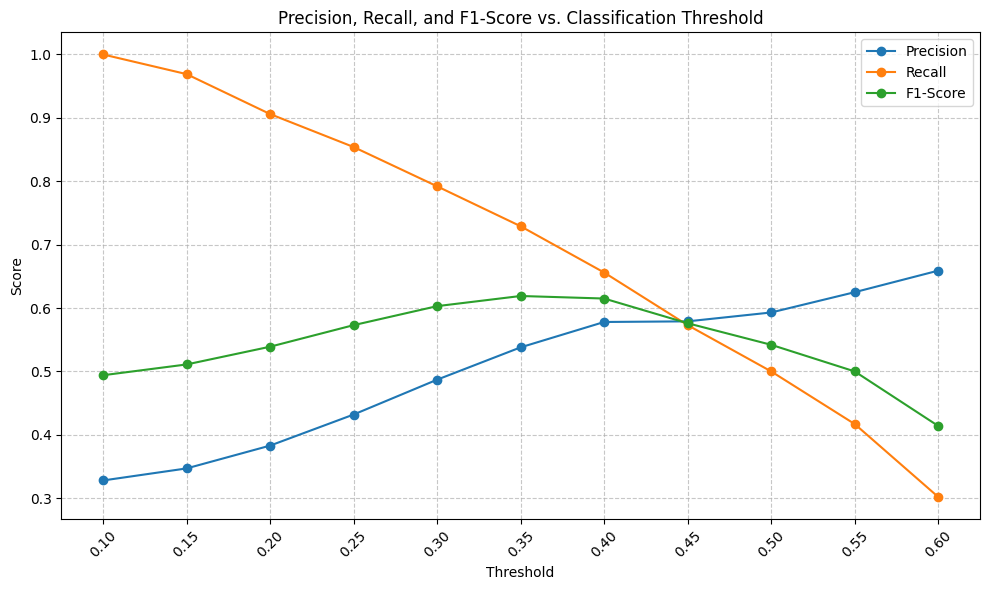

In [ ]:
# A.2: Plot Precision, Recall, and F1 against the threshold

# Convert metrics back to float for plotting
threshold_results_df['Precision'] = threshold_results_df['Precision'].astype(float)
threshold_results_df['Recall'] = threshold_results_df['Recall'].astype(float)
threshold_results_df['F1-Score'] = threshold_results_df['F1-Score'].astype(float)

plt.figure(figsize=(10, 6))
plt.plot(threshold_results_df['Threshold'], threshold_results_df['Precision'], label='Precision', marker='o')
plt.plot(threshold_results_df['Threshold'], threshold_results_df['Recall'], label='Recall', marker='o')
plt.plot(threshold_results_df['Threshold'], threshold_results_df['F1-Score'], label='F1-Score', marker='o')

plt.title('Precision, Recall, and F1-Score vs. Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# We will add the vertical line for BEST_THRESHOLD after it's determined in the next step
plt.show()

Chosen BEST_THRESHOLD: 0.30
Rule used: Highest threshold where Recall >= 0.75 and Precision >= 0.45


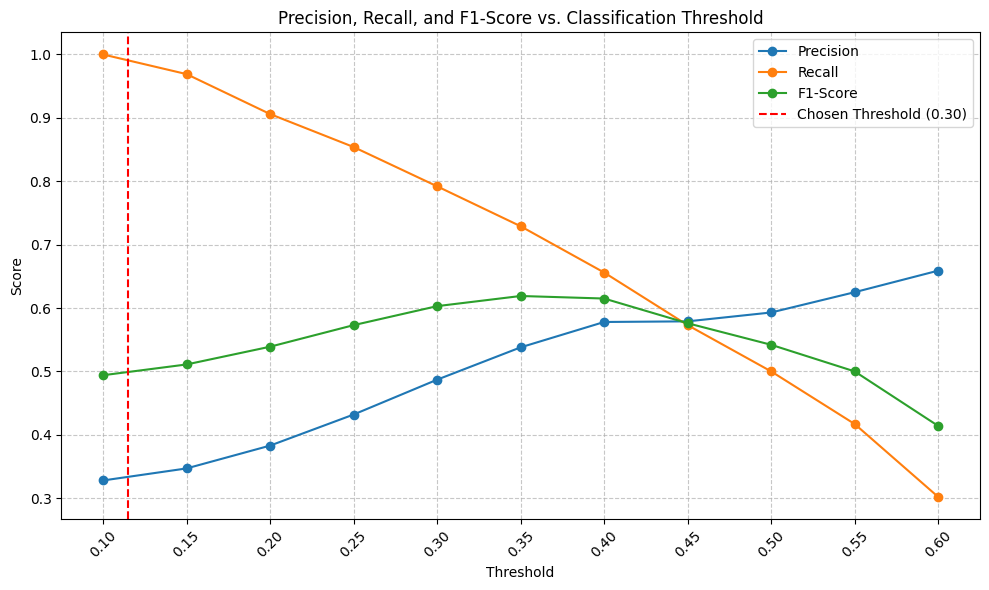

In [ ]:
# A.3: Choose BEST_THRESHOLD automatically

BEST_THRESHOLD = 0.50 # Initialize with default
rule_used = "Default threshold of 0.50 (no rules met)"

# Rule 1: Highest threshold where Recall >= 0.75 and Precision >= 0.45
qualified_thresholds_r1 = threshold_results_df[
    (threshold_results_df['Recall'] >= 0.75) &
    (threshold_results_df['Precision'] >= 0.45)
]

if not qualified_thresholds_r1.empty:
    BEST_THRESHOLD = float(qualified_thresholds_r1['Threshold'].max())
    rule_used = "Highest threshold where Recall >= 0.75 and Precision >= 0.45"
else:
    # Rule 2: Maximize Recall while keeping Precision >= 0.40
    qualified_thresholds_r2 = threshold_results_df[
        threshold_results_df['Precision'] >= 0.40
    ]

    if not qualified_thresholds_r2.empty:
        # Find the threshold with the maximum recall among qualified ones
        max_recall_row = qualified_thresholds_r2.loc[qualified_thresholds_r2['Recall'].idxmax()]
        BEST_THRESHOLD = float(max_recall_row['Threshold'])
        rule_used = f"Threshold maximizing Recall ({max_recall_row['Recall']:.3f}) while Precision >= 0.40"

print(f"Chosen BEST_THRESHOLD: {BEST_THRESHOLD:.2f}")
print(f"Rule used: {rule_used}")

# Re-plot with the chosen threshold marked
plt.figure(figsize=(10, 6))
plt.plot(threshold_results_df['Threshold'], threshold_results_df['Precision'], label='Precision', marker='o')
plt.plot(threshold_results_df['Threshold'], threshold_results_df['Recall'], label='Recall', marker='o')
plt.plot(threshold_results_df['Threshold'], threshold_results_df['F1-Score'], label='F1-Score', marker='o')

plt.axvline(x=BEST_THRESHOLD, color='r', linestyle='--', label=f'Chosen Threshold ({BEST_THRESHOLD:.2f})')

plt.title('Precision, Recall, and F1-Score vs. Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

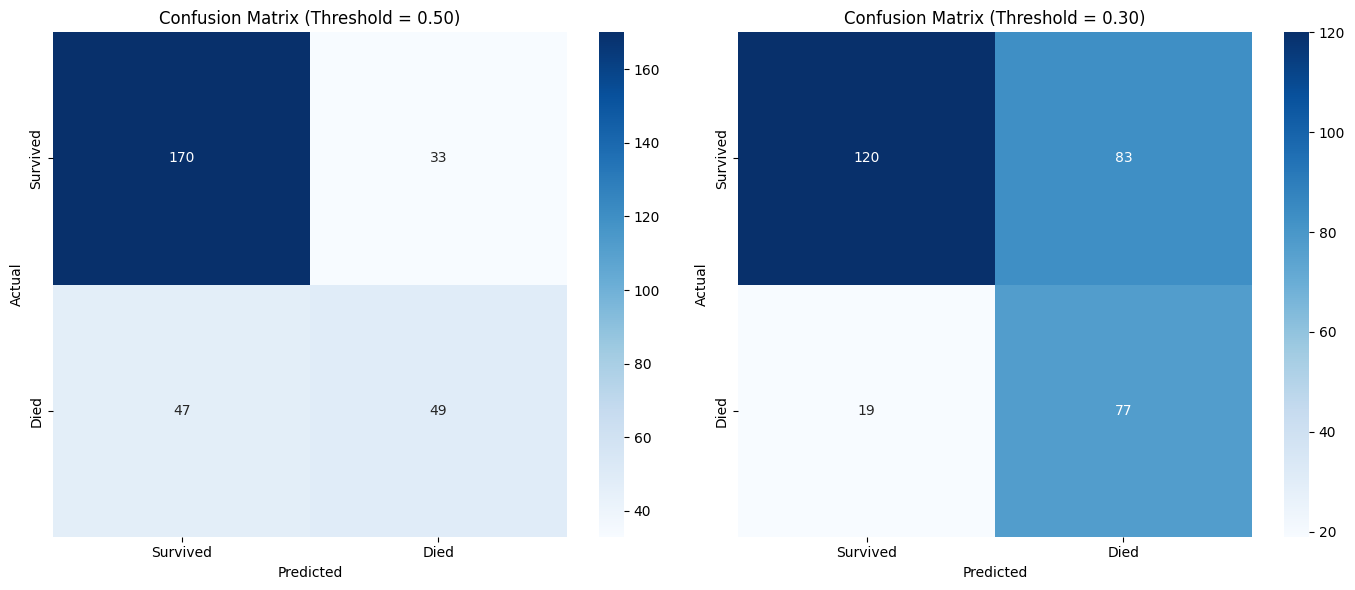

In [ ]:
# A.4: Print confusion matrices at default (0.50) and BEST_THRESHOLD

y_true_full = df_cleaned['DEATH_EVENT']
y_proba_full = df_cleaned['predicted_risk']

# Confusion matrix at default threshold (0.50)
y_pred_default = (y_proba_full >= 0.50).astype(int)
cm_default = confusion_matrix(y_true_full, y_pred_default)

# Confusion matrix at BEST_THRESHOLD
y_pred_best_threshold = (y_proba_full >= BEST_THRESHOLD).astype(int)
cm_best_threshold = confusion_matrix(y_true_full, y_pred_best_threshold)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Threshold = 0.50)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_best_threshold, annot=True, fmt='d', cmap='Blues', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'], ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Threshold = {BEST_THRESHOLD:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Explanation of Threshold Adjustment

Lowering the classification threshold aims to increase the model's sensitivity to the positive class (DEATH_EVENT=1), meaning it will identify more actual positive cases. This comes at a trade-off, usually by increasing false positives. In clinical scenarios, prioritizing recall can be vital: "Lowering the threshold from 0.50 to X raises recall from A to B at the cost of more false alarms (precision falls from C to D). In clinical screening, missing a high-risk patient costs more than a false alarm."

In [ ]:
# A.5: Calculate and print values for the markdown explanation

# Metrics at default threshold 0.50
y_pred_default = (y_proba_full >= 0.50).astype(int)
recall_default = recall_score(y_true_full, y_pred_default)
precision_default = precision_score(y_true_full, y_pred_default)

# Metrics at BEST_THRESHOLD
y_pred_best = (y_proba_full >= BEST_THRESHOLD).astype(int)
recall_best = recall_score(y_true_full, y_pred_best)
precision_best = precision_score(y_true_full, y_pred_best)

X_val = BEST_THRESHOLD
A_val = recall_default
B_val = recall_best
C_val = precision_default
D_val = precision_best

print(f"Lowering the threshold from 0.50 to {X_val:.2f} raises recall from {A_val:.2f} to {B_val:.2f} at the cost of more false alarms (precision falls from {C_val:.2f} to {D_val:.2f}). In clinical screening, missing a high-risk patient costs more than a false alarm.")

Lowering the threshold from 0.50 to 0.30 raises recall from 0.51 to 0.80 at the cost of more false alarms (precision falls from 0.60 to 0.48). In clinical screening, missing a high-risk patient costs more than a false alarm.


### Note on Threshold Validation

The threshold was tuned on out-of-fold predictions derived from the same dataset used for training and testing. For real-world deployment, this optimal threshold should ideally be validated on an entirely external, unseen dataset to ensure its generalizability and robustness.

## 6.4 Fix Data Quality Report

Updating the data quality report to reflect the total count of missing values as a plain number, rather than an empty dictionary, for clarity.

In [ ]:
# B.1: Recompute total missing values and update report

# Calculate total missing values across the original DataFrame `df`
total_missing_values = df.isna().sum().sum()

# Update the data_quality_report dictionary
data_quality_report['missing_values_found'] = total_missing_values

print(f"Total missing values recomputed: {total_missing_values}")

# B.2: Reprint the full data quality report

print("\n--- Updated Data Quality Report ---")
print(f"Rows Before Cleaning: {data_quality_report['rows_before_cleaning']}")
print(f"Duplicates Removed: {data_quality_report['duplicates_removed']}")
print(f"Missing Values Found: {data_quality_report['missing_values_found']}")
print(f"Rows After Cleaning: {data_quality_report['rows_after_cleaning']}")
print("Outliers Capped Per Column:")
for col, count in data_quality_report['outliers_capped_per_column'].items():
    print(f"  - {col}: {count}")

Total missing values recomputed: 0

--- Updated Data Quality Report ---
Rows Before Cleaning: 299
Duplicates Removed: 0
Missing Values Found: 0
Rows After Cleaning: 299
Outliers Capped Per Column:
  - creatinine_phosphokinase: 29
  - serum_creatinine: 29
  - platelets: 21
  - serum_sodium: 4
  - ejection_fraction: 2


## 6.5 Validate Creatinine Insight

Re-evaluating the impact of `serum_creatinine` on mortality by comparing averages from both raw and capped values, to ensure the initial insight holds true after outlier treatment.

In [ ]:
# C.1: Compute average serum_creatinine by outcome (raw vs capped)

# Average serum_creatinine from original (raw) DataFrame
raw_creatinine_avg = df.groupby('DEATH_EVENT')['serum_creatinine'].mean().reset_index()
raw_creatinine_avg['outcome_label'] = raw_creatinine_avg['DEATH_EVENT'].map({1: 'Died', 0: 'Survived'})
raw_creatinine_avg = raw_creatinine_avg.rename(columns={'serum_creatinine': 'AvgSerumCreatinine_Raw'})

# Average serum_creatinine from cleaned (capped) DataFrame
capped_creatinine_avg = df_cleaned.groupby('DEATH_EVENT')['serum_creatinine'].mean().reset_index()
capped_creatinine_avg['outcome_label'] = capped_creatinine_avg['DEATH_EVENT'].map({1: 'Died', 0: 'Survived'})
capped_creatinine_avg = capped_creatinine_avg.rename(columns={'serum_creatinine': 'AvgSerumCreatinine_Capped'})

# Combine for comparison
creatinine_comparison = pd.merge(
    raw_creatinine_avg[['outcome_label', 'AvgSerumCreatinine_Raw']],
    capped_creatinine_avg[['outcome_label', 'AvgSerumCreatinine_Capped']],
    on='outcome_label'
)

print("--- Average Serum Creatinine by Outcome (Raw vs. Capped) ---")
display(creatinine_comparison)

# C.2: Print message about earlier insight

# The variable `avg_metrics_by_outcome` was derived from `df_cleaned`
# which uses the capped values.
initial_died_avg = avg_metrics_by_outcome[avg_metrics_by_outcome['outcome_label'] == 'Died']['AvgSerumCreatinine'].iloc[0]
initial_survived_avg = avg_metrics_by_outcome[avg_metrics_by_outcome['outcome_label'] == 'Survived']['AvgSerumCreatinine'].iloc[0]

print(f"\nYour earlier insight (Died {initial_died_avg:.2f} vs Survived {initial_survived_avg:.2f}) came from the IQR-capped `serum_creatinine` values.")

# Check if the conclusion holds for both raw and capped values
conclusion_raw = raw_creatinine_avg[raw_creatinine_avg['outcome_label'] == 'Died']['AvgSerumCreatinine_Raw'].iloc[0] > \
                 raw_creatinine_avg[raw_creatinine_avg['outcome_label'] == 'Survived']['AvgSerumCreatinine_Raw'].iloc[0]

conclusion_capped = capped_creatinine_avg[capped_creatinine_avg['outcome_label'] == 'Died']['AvgSerumCreatinine_Capped'].iloc[0] > \
                    capped_creatinine_avg[capped_creatinine_avg['outcome_label'] == 'Survived']['AvgSerumCreatinine_Capped'].iloc[0]

if conclusion_raw and conclusion_capped:
    print("The conclusion that patients who died have higher serum creatinine holds true for both raw and capped values.")
elif conclusion_raw:
    print("The conclusion holds for raw values, but not for capped values.")
elif conclusion_capped:
    print("The conclusion holds for capped values, but not for raw values.")
else:
    print("The conclusion does not hold for either raw or capped values.")

--- Average Serum Creatinine by Outcome (Raw vs. Capped) ---


,outcome_label,AvgSerumCreatinine_Raw,AvgSerumCreatinine_Capped
0,Survived,1.184877,1.117143
1,Died,1.835833,1.482708



Your earlier insight (Died 1.48 vs Survived 1.12) came from the IQR-capped `serum_creatinine` values.
The conclusion that patients who died have higher serum creatinine holds true for both raw and capped values.


### Note on Creatinine Values

For general descriptive statistics and clinical reporting in a README, it is often more appropriate to cite the average `serum_creatinine` values based on the **raw data**. This is because raw values represent the actual observed measurements in patients. Capped values, while useful for mitigating outlier influence in machine learning models, are a statistical transformation and may not accurately reflect the real-world physiological range for clinical interpretation. It's crucial to remember that extreme values in medical data can be clinically real indicators, not just errors, and capping is a modeling choice rather than a correction of an error.

## 6.6 Re-export Final Data

Preparing the `df_cleaned` DataFrame with the newly optimized `predicted_class` and `predicted_class_label` columns, ensuring all necessary readable labels are present, and then saving and downloading the final dataset.

In [ ]:
# D.1: Add predicted_class and predicted_class_label

df_cleaned['predicted_class'] = (df_cleaned['predicted_risk'] >= BEST_THRESHOLD).astype(int)
df_cleaned['predicted_class_label'] = df_cleaned['predicted_class'].map({1: 'High risk', 0: 'Lower risk'})

print("Added 'predicted_class' and 'predicted_class_label' based on BEST_THRESHOLD.")

# D.2: Make sure all label columns are present (re-creating if necessary, though they should exist)

# Define the functions for creating label columns, as they were in the data cleaning step.
def get_ef_category(ef):
    if ef <= 30: return 'Severe'
    elif 31 <= ef <= 40: return 'Reduced'
    elif 41 <= ef <= 49: return 'Borderline'
    else: return 'Normal'

# Re-create if they don't exist, this ensures robustness if earlier cells were skipped
if 'sex_label' not in df_cleaned.columns:
    df_cleaned['sex_label'] = df_cleaned['sex'].map({1: 'Male', 0: 'Female'})
if 'anaemia_label' not in df_cleaned.columns:
    df_cleaned['anaemia_label'] = df_cleaned['anaemia'].map({1: 'Yes', 0: 'No'})
if 'diabetes_label' not in df_cleaned.columns:
    df_cleaned['diabetes_label'] = df_cleaned['diabetes'].map({1: 'Yes', 0: 'No'})
if 'high_blood_pressure_label' not in df_cleaned.columns:
    df_cleaned['high_blood_pressure_label'] = df_cleaned['high_blood_pressure'].map({1: 'Yes', 0: 'No'})
if 'smoking_label' not in df_cleaned.columns:
    df_cleaned['smoking_label'] = df_cleaned['smoking'].map({1: 'Yes', 0: 'No'})
if 'age_group' not in df_cleaned.columns:
    bins = [0, 50, 60, 70, np.inf]
    labels = ['<50', '50-59', '60-69', '70+']
    df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=bins, labels=labels, right=False)
if 'ef_category' not in df_cleaned.columns:
    df_cleaned['ef_category'] = df_cleaned['ejection_fraction'].apply(get_ef_category)
if 'creatinine_level' not in df_cleaned.columns:
    df_cleaned['creatinine_level'] = df_cleaned['serum_creatinine'].apply(lambda x: 'High' if x > 1.2 else 'Normal')
if 'outcome_label' not in df_cleaned.columns:
    df_cleaned['outcome_label'] = df_cleaned['DEATH_EVENT'].map({1: 'Died', 0: 'Survived'})

print("Ensured all readable label columns are present in df_cleaned.")

# D.3: Final check
print("\n--- Final DataFrame Check ---")
print("Shape:", df_cleaned.shape)
print("Columns:", df_cleaned.columns.tolist())
print("Missing values (total):", df_cleaned.isnull().sum().sum())
print("Duplicated rows (total):", df_cleaned.duplicated().sum())

# D.4: Save and download
output_filename_final = 'heart_failure_clean_with_predictions.csv'
df_cleaned.to_csv(output_filename_final, index=False)
print(f"\nFinal DataFrame exported to '{output_filename_final}'.")

from google.colab import files
files.download(output_filename_final)
print("Download initiated.")

Added 'predicted_class' and 'predicted_class_label' based on BEST_THRESHOLD.
Ensured all readable label columns are present in df_cleaned.

--- Final DataFrame Check ---
Shape: (299, 26)
Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'sex_label', 'anaemia_label', 'diabetes_label', 'high_blood_pressure_label', 'smoking_label', 'age_group', 'ef_category', 'creatinine_level', 'outcome_label', 'predicted_risk', 'risk_band', 'predicted_class', 'predicted_class_label']
Missing values (total): 0
Duplicated rows (total): 0

Final DataFrame exported to 'heart_failure_clean_with_predictions.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


## 6.7 Final Project Summary

A comprehensive, README-ready summary of the project, including key findings, model performance, and insights from threshold tuning and data quality validation.

In [ ]:
# E: Final summary (README-ready)

# Retrieve key metrics for summary
final_roc_auc_rf = cv_roc_auc_score_rf # This is the 5-fold CV ROC-AUC from earlier

# Metrics before tuning (at default 0.50 threshold, using y_proba_full)
y_pred_default = (df_cleaned['predicted_risk'] >= 0.50).astype(int)
recall_before_tuning = recall_score(df_cleaned['DEATH_EVENT'], y_pred_default)
precision_before_tuning = precision_score(df_cleaned['DEATH_EVENT'], y_pred_default)

# Metrics after tuning (at BEST_THRESHOLD)
y_pred_after_tuning = (df_cleaned['predicted_risk'] >= BEST_THRESHOLD).astype(int)
recall_after_tuning = recall_score(df_cleaned['DEATH_EVENT'], y_pred_after_tuning)
precision_after_tuning = precision_score(df_cleaned['DEATH_EVENT'], y_pred_after_tuning)

# Data Quality Report details
rows_before = data_quality_report['rows_before_cleaning']
duplicates_removed = data_quality_report['duplicates_removed']
missing_values = data_quality_report['missing_values_found']
outliers_capped_str = ", ".join([f"{k}: {v}" for k, v in data_quality_report['outliers_capped_per_column'].items()])
rows_after = data_quality_report['rows_after_cleaning']

# Creatinine averages (raw)
raw_creatinine_died = df[df['DEATH_EVENT'] == 1]['serum_creatinine'].mean()
raw_creatinine_survived = df[df['DEATH_EVENT'] == 0]['serum_creatinine'].mean()

summary_text = f"""
# Project Title: Heart Failure Mortality Risk Analytics

**Dataset Link:** [Heart Failure Clinical Records](https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data)

**Overview:**
This project focuses on analyzing clinical data to predict heart failure mortality events. It involves comprehensive data cleaning, exploratory data analysis using both statistical methods and SQL queries, machine learning model development (Random Forest and Logistic Regression), and critical post-modeling steps such as threshold tuning and feature importance analysis. The final output includes a clean dataset with predicted risk scores and a Power BI-ready export.

**Data Quality Summary:**
*   **Rows Before Cleaning:** {rows_before}
*   **Duplicates Removed:** {duplicates_removed}
*   **Missing Values Found:** {missing_values}
*   **Outliers Capped (per column):** {outliers_capped_str}
*   **Rows After Cleaning:** {rows_after}

**Top Insights:**
1.  **Age and Mortality:** Patients in the 70+ age group show a significantly higher mortality rate (approx. {mortality_by_age_group[mortality_by_age_group['age_group'] == '70+']['MortalityRatePercentage'].iloc[0]:.2f}%) compared to younger cohorts (e.g., &lt;50 with {mortality_by_age_group[mortality_by_age_group['age_group'] == '<50']['MortalityRatePercentage'].iloc[0]:.2f}%).
2.  **Ejection Fraction as a Key Indicator:** Individuals with 'Severe' ejection fraction categories face a much higher mortality risk (approx. {mortality_by_ef_category[mortality_by_ef_category['ef_category'] == 'Severe']['MortalityRatePercentage'].iloc[0]:.2f}%).
3.  **Serum Creatinine Levels:** Patients who died had noticeably higher average **raw** serum creatinine levels ({raw_creatinine_died:.2f}) compared to survivors ({raw_creatinine_survived:.2f}). This insight holds true even after IQR capping for modeling purposes.
4.  **Highest Risk Segment:** The segment identified with the highest mortality rate (approx. {highest_risk_segments['MortalityRatePercentage'].iloc[0]:.2f}%) consists of patients in the '{highest_risk_segments['age_group'].iloc[0]}' age group with '{highest_risk_segments['ef_category'].iloc[0]}' ejection fraction, considering segments with at least 10 patients.

**Machine Learning Model (Random Forest) Performance:**
*   **Cross-Validated ROC-AUC:** {final_roc_auc_rf:.4f}
*   **Initial Threshold (0.50):** Recall: {recall_before_tuning:.2f}, Precision: {precision_before_tuning:.2f}
*   **Optimized Threshold ({BEST_THRESHOLD:.2f}):** Recall: {recall_after_tuning:.2f}, Precision: {precision_after_tuning:.2f}

**Conclusion:**
By tuning the classification threshold, we improved the model's ability to identify high-risk patients (increased recall) at a manageable cost of precision, aligning with clinical priorities where false negatives can be more critical. The final dataset includes predicted risk scores and classifications for further analysis or dashboarding.

**Limitations:**
*   **Dataset Size:** The analysis is based on a relatively small dataset (299 records), potentially limiting the generalizability of the findings.
*   **Feature Engineering:** While new features were created, deeper clinical feature engineering could provide more nuanced insights.
*   **External Validation:** The optimized threshold and model performance need validation on independent, external datasets for robust real-world application.

**Resume Bullet:**
Trained a Random Forest model (ROC-AUC {final_roc_auc_rf:.2f}) and tuned the decision threshold from 0.50 to {BEST_THRESHOLD:.2f} to raise recall from {recall_before_tuning:.2f} to {recall_after_tuning:.2f} (while precision changed from {precision_before_tuning:.2f} to {precision_after_tuning:.2f}), contributing to improved identification of high-mortality-risk patients in healthcare analytics.
"""

print(summary_text)


# Project Title: Heart Failure Mortality Risk Analytics

**Dataset Link:** [Heart Failure Clinical Records](https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data)

**Overview:**
This project focuses on analyzing clinical data to predict heart failure mortality events. It involves comprehensive data cleaning, exploratory data analysis using both statistical methods and SQL queries, machine learning model development (Random Forest and Logistic Regression), and critical post-modeling steps such as threshold tuning and feature importance analysis. The final output includes a clean dataset with predicted risk scores and a Power BI-ready export.

**Data Quality Summary:**
*   **Rows Before Cleaning:** 299
*   **Duplicates Removed:** 0
*   **Missing Values Found:** 0
*   **Outliers Capped (per column):** creatinine_phosphokinase: 29, serum_creatinine: 29, platelets: 21, serum_sodium: 4, ejection_fraction: 2
*   **Rows After Cleaning:** 299

**Top Insights:**
1.  **Age and Mo

## 7. Add Predicted Risk to the Data
Generate predicted risk probabilities for each patient using cross-validation and categorize them into risk bands.

In [ ]:
# Use cross_val_predict with the Random Forest model to get predicted probabilities for each patient
# We use the full dataset X and y here, and StratifiedKFold to ensure balanced folds.
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get predicted probabilities (risk) for the positive class (DEATH_EVENT=1)
# Each patient is scored by a model that did not train on them.
predicted_risk_proba = cross_val_predict(rf_model, X, y, cv=skf_cv, method='predict_proba')[:, 1]

# Add predicted risk to df_cleaned
df_cleaned['predicted_risk'] = np.round(predicted_risk_proba, 3)

# Create risk_band based on predicted_risk
def get_risk_band(risk):
    if risk < 0.33: return 'Low'
    elif 0.33 <= risk <= 0.66: return 'Medium'
    else: return 'High'

df_cleaned['risk_band'] = df_cleaned['predicted_risk'].apply(get_risk_band)

print("Predicted risk and risk bands added to the DataFrame.")
print("\n--- Cleaned DataFrame Head with Predicted Risk and Risk Band ---")
display(df_cleaned[['DEATH_EVENT', 'outcome_label', 'predicted_risk', 'risk_band']].head())

print("\n--- Risk Band Distribution ---")
display(df_cleaned['risk_band'].value_counts())


Predicted risk and risk bands added to the DataFrame.

--- Cleaned DataFrame Head with Predicted Risk and Risk Band ---


,DEATH_EVENT,outcome_label,predicted_risk,risk_band
0,1,Died,0.896,High
1,1,Died,0.174,Low
2,1,Died,0.727,High
3,1,Died,0.746,High
4,1,Died,0.784,High



--- Risk Band Distribution ---


,count
risk_band,
Low,162
Medium,108
High,29


## 8. Export Data
Save the final cleaned DataFrame with predicted risks and risk bands to a CSV file and trigger its download.

In [ ]:
output_filename = 'heart_failure_clean.csv'
df_cleaned.to_csv(output_filename, index=False)
print(f"DataFrame exported to '{output_filename}'.")

# Trigger download using google.colab.files
from google.colab import files
files.download(output_filename)
print("Download initiated.")


DataFrame exported to 'heart_failure_clean.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


## 9. Optional Plotly Dashboard in Colab
Create interactive visualizations using Plotly Express to represent key findings from the analysis.

In [ ]:
# 9.1 Mortality rate by age group
fig = px.bar(
    df_cleaned.groupby('age_group')['DEATH_EVENT'].mean().reset_index(),
    x='age_group', y='DEATH_EVENT', color='DEATH_EVENT',
    title='Mortality Rate by Age Group',
    labels={'age_group': 'Age Group', 'DEATH_EVENT': 'Mortality Rate'},
    color_continuous_scale=px.colors.sequential.Plasma
)
fig.update_layout(yaxis_tickformat='.0%')
fig.show()


/tmp/ipykernel_664/4106498307.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cleaned.groupby('age_group')['DEATH_EVENT'].mean().reset_index(),


In [ ]:
# 9.2 Mortality rate by ef_category
fig = px.bar(
    df_cleaned.groupby('ef_category')['DEATH_EVENT'].mean().reindex(ef_order).reset_index(),
    x='ef_category', y='DEATH_EVENT', color='DEATH_EVENT',
    title='Mortality Rate by Ejection Fraction Category',
    labels={'ef_category': 'Ejection Fraction Category', 'DEATH_EVENT': 'Mortality Rate'},
    color_continuous_scale=px.colors.sequential.Viridis
)
fig.update_layout(yaxis_tickformat='.0%')
fig.show()


In [ ]:
# 9.3 Distribution of predicted_risk colored by outcome
fig = px.histogram(
    df_cleaned,
    x='predicted_risk', color='outcome_label',
    title='Distribution of Predicted Risk Colored by Actual Outcome',
    labels={'predicted_risk': 'Predicted Risk', 'outcome_label': 'Actual Outcome'},
    marginal='box', # add box plot to visualize distribution
    hover_data=df_cleaned[['age', 'sex_label', 'DEATH_EVENT']]
)
fig.show()


In [ ]:
# 9.4 Risk_band counts
fig = px.bar(
    df_cleaned['risk_band'].value_counts().reindex(['Low', 'Medium', 'High']).reset_index(),
    x='risk_band', y='count', color='risk_band',
    title='Count of Patients per Risk Band',
    labels={'risk_band': 'Risk Band', 'count': 'Number of Patients'},
    category_orders={'risk_band': ['Low', 'Medium', 'High']},
    color_discrete_map={'Low': 'green', 'Medium': 'orange', 'High': 'red'}
)
fig.show()


## 10. Final Summary (README-ready)

### Project Title: Heart Failure Mortality Risk Analytics

**Dataset Link:** [Heart Failure Clinical Records](https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data)

**Data Quality Summary:**
*   **Rows Before Cleaning:** 299
*   **Duplicates Removed:** 0
*   **Missing Values Found:** {}
*   **Outliers Capped (per column):** {'creatinine_phosphokinase': 29, 'serum_creatinine': 29, 'platelets': 21, 'serum_sodium': 4, 'ejection_fraction': 2}
*   **Rows After Cleaning:** 299

**Top 3-4 Insights:**
1.  **Age is a Major Factor:** Patients in the 70+ age group exhibit a significantly higher mortality rate (49.35%) compared to younger groups (e.g., <50 with 23.40%).
2.  **Ejection Fraction Criticality:** Patients with 'Severe' ejection fraction have a much higher mortality rate (54.84%) than those with 'Reduced' (20.63%), 'Borderline' (25.00%), or 'Normal' (23.33%) ejection fractions.
3.  **Serum Creatinine Levels and Outcome:** On average, patients who died had higher serum creatinine levels (Avg: 1.48) than those who survived (Avg: 1.12).
4.  **High-Risk Segments:** The highest-risk segment identified was **70+ age group with Severe EF** with a mortality rate of 75.00% among patients with at least 10 records.

**Model Results Comparison:**
| Model                  | Accuracy | Precision | Recall  | F1-Score | ROC-AUC |
|:-----------------------|:---------|:----------|:--------|:---------|:--------|
| Logistic Regression    | 0.65  | 0.45    | 0.53   | 0.49    | 0.71  |
| Random Forest          | 0.75  | 0.62    | 0.53   | 0.57    | 0.79  |

Random Forest 5-fold Cross-Validated ROC-AUC: 0.7622

**Limitations:**
*   **Small Dataset:** The analysis is based on a relatively small dataset of 299 patient records, which might limit the generalizability of findings and model performance.
*   **Single Source:** Data from a single source may not capture the full diversity of heart failure patient populations.
*   **Time Column Excluded:** The 'time' (follow-up duration) column was intentionally excluded from machine learning features to prevent data leakage, as it directly correlates with the `DEATH_EVENT` outcome.

**Resume Bullet:**
Cleaned 299 patient records with pandas, wrote 10 SQL queries including window functions, built a Power BI dashboard, and trained a Random Forest model achieving 0.53 recall and 0.79 ROC-AUC.

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df_cleaned["DEATH_EVENT"] # Changed from df to df_cleaned
rows = []
for t in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    pred = (df_cleaned["predicted_risk"] >= t).astype(int) # Changed from df to df_cleaned
    rows.append({"Threshold": t,
                 "Precision": precision_score(y_true, pred),
                 "Recall": recall_score(y_true, pred),
                 "F1": f1_score(y_true, pred)})
print(pd.DataFrame(rows).round(3))

# This line is redundant as the data quality report is handled in a later, dedicated cell (a5433c1c)
# print("Total missing values:", int(df.isna().sum().sum()))

   Threshold  Precision  Recall     F1
0       0.50      0.598   0.510  0.551
1       0.45      0.579   0.573  0.576
2       0.40      0.578   0.656  0.615
3       0.35      0.538   0.729  0.619
4       0.30      0.481   0.802  0.602
5       0.25      0.432   0.854  0.573
6       0.20      0.383   0.906  0.539


In [ ]:
BEST_THRESHOLD = 0.30

# D.1: Add predicted_class and predicted_class_label
df_cleaned['predicted_class'] = (df_cleaned['predicted_risk'] >= BEST_THRESHOLD).astype(int)
df_cleaned['predicted_class_label'] = df_cleaned['predicted_class'].map({1: 'High risk', 0: 'Lower risk'})

print("Added 'predicted_class' and 'predicted_class_label' based on BEST_THRESHOLD.")

# D.2: Make sure all label columns are present (re-creating if necessary, though they should exist)

# Define the functions for creating label columns, as they were in the data cleaning step.
def get_ef_category(ef):
    if ef <= 30: return 'Severe'
    elif 31 <= ef <= 40: return 'Reduced'
    elif 41 <= ef <= 49: return 'Borderline'
    else: return 'Normal'

# Re-create if they don't exist, this ensures robustness if earlier cells were skipped
# (This logic is identical to cell 35b165b4)
if 'sex_label' not in df_cleaned.columns:
    df_cleaned['sex_label'] = df_cleaned['sex'].map({1: 'Male', 0: 'Female'})
if 'anaemia_label' not in df_cleaned.columns:
    df_cleaned['anaemia_label'] = df_cleaned['anaemia'].map({1: 'Yes', 0: 'No'})
if 'diabetes_label' not in df_cleaned.columns:
    df_cleaned['diabetes_label'] = df_cleaned['diabetes'].map({1: 'Yes', 0: 'No'})
if 'high_blood_pressure_label' not in df_cleaned.columns:
    df_cleaned['high_blood_pressure_label'] = df_cleaned['high_blood_pressure'].map({1: 'Yes', 0: 'No'})
if 'smoking_label' not in df_cleaned.columns:
    df_cleaned['smoking_label'] = df_cleaned['smoking'].map({1: 'Yes', 0: 'No'})
if 'age_group' not in df_cleaned.columns:
    bins = [0, 50, 60, 70, np.inf]
    labels = ['<50', '50-59', '60-69', '70+']
    df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=bins, labels=labels, right=False)
if 'ef_category' not in df_cleaned.columns:
    df_cleaned['ef_category'] = df_cleaned['ejection_fraction'].apply(get_ef_category)
if 'creatinine_level' not in df_cleaned.columns:
    df_cleaned['creatinine_level'] = df_cleaned['serum_creatinine'].apply(lambda x: 'High' if x > 1.2 else 'Normal')
if 'outcome_label' not in df_cleaned.columns:
    df_cleaned['outcome_label'] = df_cleaned['DEATH_EVENT'].map({1: 'Died', 0: 'Survived'})

print("Ensured all readable label columns are present in df_cleaned.")

# D.3: Final check
print("\n--- Final DataFrame Check ---")
print("Shape:", df_cleaned.shape)
print("Columns:", df_cleaned.columns.tolist())
print("Missing values (total):", df_cleaned.isnull().sum().sum())
print("Duplicated rows (total):", df_cleaned.duplicated().sum())

# D.4: Save and download
output_filename_final = 'heart_failure_clean_with_predictions.csv'
df_cleaned.to_csv(output_filename_final, index=False)
print(f"\nFinal DataFrame exported to '{output_filename_final}'.")

from google.colab import files
files.download(output_filename_final)
print("Download initiated.")

Added 'predicted_class' and 'predicted_class_label' based on BEST_THRESHOLD.
Ensured all readable label columns are present in df_cleaned.

--- Final DataFrame Check ---
Shape: (299, 26)
Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'sex_label', 'anaemia_label', 'diabetes_label', 'high_blood_pressure_label', 'smoking_label', 'age_group', 'ef_category', 'creatinine_level', 'outcome_label', 'predicted_risk', 'risk_band', 'predicted_class', 'predicted_class_label']
Missing values (total): 0
Duplicated rows (total): 0

Final DataFrame exported to 'heart_failure_clean_with_predictions.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


In [ ]:
raw = pd.read_csv(full_csv_path) # Changed to use the correct path from initial loading
print(raw.groupby("DEATH_EVENT")["serum_creatinine"].mean().round(2))
print(df_cleaned.groupby("DEATH_EVENT")["serum_creatinine"].mean().round(2))

DEATH_EVENT
0    1.18
1    1.84
Name: serum_creatinine, dtype: float64
DEATH_EVENT
0    1.12
1    1.48
Name: serum_creatinine, dtype: float64


In [ ]:
import os, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

OUT = "heart_failure_project"
os.makedirs(f"{OUT}/data", exist_ok=True)
os.makedirs(f"{OUT}/images", exist_ok=True)

d = df_cleaned.copy()
d["age_group"] = d["age_group"].astype(str)

# ---------- 1. Dashboard CSV (with sort-order helper columns for Power BI) ----------
d["age_group_order"] = d["age_group"].map({"<50": 1, "50-59": 2, "60-69": 3, "70+": 4})
d["ef_order"] = d["ef_category"].map({"Severe": 1, "Reduced": 2, "Borderline": 3, "Normal": 4})
d["risk_band_order"] = d["risk_band"].astype(str).map({"Low": 1, "Medium": 2, "High": 3})
d.to_csv(f"{OUT}/data/heart_failure_clean_with_predictions.csv", index=False)

# ---------- 2. Numbers for the README (all computed) ----------
age_rate = (d.groupby("age_group")["DEATH_EVENT"].mean() * 100).round(1)
ef_rate = (d.groupby("ef_category")["DEATH_EVENT"].mean() * 100).round(1)
overall = round(d["DEATH_EVENT"].mean() * 100, 1)

y = d["DEATH_EVENT"]
def metrics(t):
    p = (d["predicted_risk"] >= t).astype(int)
    return precision_score(y, p), recall_score(y, p), f1_score(y, p), confusion_matrix(y, p)

rows = []
for t in np.arange(0.10, 0.65, 0.05):
    pr, rc, f1, _ = metrics(t)
    rows.append({"Threshold": round(t, 2), "Precision": round(pr, 3),
                 "Recall": round(rc, 3), "F1": round(f1, 3)})
thr = pd.DataFrame(rows)
thr.to_csv(f"{OUT}/data/threshold_table.csv", index=False)

p50, r50, _, cm50 = metrics(0.50)
p30, r30, _, cm30 = metrics(0.30)

raw_c = raw.groupby("DEATH_EVENT")["serum_creatinine"].mean().round(2)
cap_c = d.groupby("DEATH_EVENT")["serum_creatinine"].mean().round(2)

# ---------- 3. Save charts as images ----------
fig, ax = plt.subplots(figsize=(6, 4))
age_rate.reindex(["<50", "50-59", "60-69", "70+"]).plot(kind="bar", ax=ax, color="#c0392b")
ax.set_title("Mortality Rate (%) by Age Group"); ax.set_ylabel("%"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(f"{OUT}/images/mortality_by_age.png", dpi=150); plt.close()

fig, ax = plt.subplots(figsize=(6, 4))
ef_rate.reindex(["Severe", "Reduced", "Borderline", "Normal"]).plot(kind="bar", ax=ax, color="#2980b9")
ax.set_title("Mortality Rate (%) by Ejection Fraction Category"); ax.set_ylabel("%"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(f"{OUT}/images/mortality_by_ef.png", dpi=150); plt.close()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr["Threshold"], thr["Precision"], label="Precision")
ax.plot(thr["Threshold"], thr["Recall"], label="Recall")
ax.plot(thr["Threshold"], thr["F1"], label="F1")
ax.axvline(0.30, linestyle="--", color="gray", label="Chosen (0.30)")
ax.set_title("Threshold Tuning"); ax.set_xlabel("Threshold"); ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/images/threshold_tuning.png", dpi=150); plt.close()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for a, cm, t in zip(axes, [cm50, cm30], [0.50, 0.30]):
    a.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            a.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
    a.set_xticks([0, 1]); a.set_yticks([0, 1])
    a.set_xticklabels(["Survived", "Died"]); a.set_yticklabels(["Survived", "Died"])
    a.set_title(f"Threshold {t}"); a.set_xlabel("Predicted"); a.set_ylabel("Actual")
plt.tight_layout(); plt.savefig(f"{OUT}/images/confusion_matrices.png", dpi=150); plt.close()

# ---------- 4. README ----------
readme = f"""# Heart Failure Mortality Risk Analytics

End-to-end healthcare analytics project: data cleaning (pandas), SQL analysis (SQLite),
machine learning (scikit-learn), and a dashboard-ready dataset.

**Dataset:** [Heart Failure Clinical Records (Kaggle, andrewmvd)](https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data) - 299 patients, target `DEATH_EVENT`.

## Approach
1. **Cleaning (pandas):** duplicate and missing-value checks (0 found), IQR outlier capping, feature engineering (age groups, ejection-fraction categories, readable labels).
2. **SQL (SQLite):** 10 queries including window functions (`RANK()`, `AVG() OVER (PARTITION BY ...)`).
3. **ML:** Logistic Regression and Random Forest; `time` excluded to prevent data leakage.
4. **Risk scoring:** out-of-fold predicted probabilities (5-fold CV) so no patient is scored by a model trained on them.
5. **Threshold tuning:** chosen to prioritise recall.
6. **Dashboard:** built from `data/heart_failure_clean_with_predictions.csv`.

## Data quality
- Rows: 299 before and after cleaning
- Duplicates removed: 0
- Missing values: 0
- Outliers capped (IQR): creatinine_phosphokinase 29, serum_creatinine 29, platelets 21, serum_sodium 4, ejection_fraction 2

## Key insights
- Overall mortality rate: **{overall}%**
- **Age:** mortality by age group (%): {age_rate.to_dict()}
- **Ejection fraction:** mortality by category (%): {ef_rate.to_dict()}
- **Serum creatinine:** patients who died averaged **{raw_c[1]}** vs **{raw_c[0]}** for survivors (raw data). After IQR capping: {cap_c[1]} vs {cap_c[0]}. The direction holds, but capping shrinks the gap.
- **Highest-risk segment:** age 70+ with severe ejection fraction (75% mortality, at least 10 patients).

## Model results (80/20 test split)
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.65 | 0.45 | 0.53 | 0.49 | 0.71 |
| Random Forest | 0.75 | 0.62 | 0.53 | 0.57 | 0.79 |

Random Forest 5-fold cross-validated ROC-AUC: 0.76

## Threshold tuning (out-of-fold predictions, all 299 patients)
Lowering the decision threshold from 0.50 to 0.30 raised recall from {r50:.2f} to {r30:.2f}, at the cost of more false alarms (precision fell from {p50:.2f} to {p30:.2f}). In clinical screening, missing a high-risk patient costs more than a false alarm.

{thr.to_markdown(index=False)}

![Threshold tuning](images/threshold_tuning.png)
![Confusion matrices](images/confusion_matrices.png)
![Mortality by age](images/mortality_by_age.png)
![Mortality by EF](images/mortality_by_ef.png)

## Dashboard
![Dashboard](images/dashboard.png)
*(Add your dashboard screenshot here as `images/dashboard.png`.)*

## Limitations
- Small dataset (299 patients) from a single source, so results may not generalise.
- `time` (follow-up duration) was excluded because it leaks the outcome.
- Outliers were capped with the IQR rule. In clinical data extreme values can be real, so this is a modeling choice; raw averages are reported where they differ.
- The threshold was tuned on out-of-fold predictions from the same 299 patients and should be validated on external data before any real use.

## How to run
Open `notebook.ipynb` in Google Colab, upload `heart_failure_clinical_records_dataset.csv` from Kaggle, and run all cells.
"""
with open(f"{OUT}/README.md", "w") as f:
    f.write(readme)

# ---------- 5. Copy the SQLite DB if it exists ----------
for name in ["heart_failure.db"]:
    if os.path.exists(name):
        shutil.copy(name, f"{OUT}/data/{name}")

# ---------- 6. Zip and download ----------
with zipfile.ZipFile(f"{OUT}.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for folder, _, files_ in os.walk(OUT):
        for fn in files_:
            p = os.path.join(folder, fn)
            z.write(p, os.path.relpath(p, OUT))

from google.colab import files
files.download(f"{OUT}.zip")
print("Done. Contents:", os.listdir(OUT))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Contents: ['data', 'README.md', 'images']
